# Deep Learning Volatility: a Neural Network Approach to the Rough Bergomi Model

**Authors:** Tom Ducard, Quentin Latil, Anastasiia Tolstineva

*Based on Horvath, Muguruza, Tomas (2019), [arXiv:1901.09647](https://arxiv.org/abs/1901.09647).*

This notebook reproduces the main numerical contributions of the paper on our own implementation of the rough Bergomi model, and extends them with two experiments. Section 6 changes the strike and maturity grid. Section 7 changes the market regime by retraining on a different parameter distribution, first testing whether the baseline network generalizes out of domain (it does not) and then showing that retraining restores accuracy.

All heavy lifting lives in the `src/` package. The notebook orchestrates and comments.

## 1. Introduction: Calibration Challenges and Computational Issues

Modeling the implied volatility surface is one of the major challenges in contemporary financial engineering. In the context of risk management and derivative pricing, a model's ability to reproduce the volatility smile observed in the market is essential. 

Traditionally, practitioners rely on stochastic volatility models such as Heston or SABR, which provide semi-analytical solutions or fast approximations. These classical frameworks struggle however to capture short-term volatility dynamics, in particular the extremely steep slope of the volatility skew for near maturities. This stylized fact is nonetheless pervasive in equity indices such as the S&P 500.

The recent emergence of rough volatility models, inspired by the work of Gatheral et al. on fractional Brownian motion with a Hurst exponent $H < 0.5$, has led to a major theoretical breakthrough. These models reconcile the historical dynamics of the underlying asset with the implied volatility surface in a remarkably parsimonious way.

This empirical accuracy comes at a cost. Unlike standard local or stochastic volatility models, rough Bergomi type models do not admit a closed-form characteristic function. Pricing European options in this framework therefore requires Monte Carlo simulations or hybrid numerical methods whose computational cost is incompatible with real-time trading constraints. Calibration, by definition an inverse problem requiring thousands of evaluations of the pricing function, becomes a technological bottleneck.

Horvath, Muguruza and Tomas address this bottleneck by replacing the traditional numerical solver with a universal approximator. A neural network is trained offline on synthetic data to map model parameters to implied volatility surfaces. Once trained, the network evaluates the pricing function in microseconds, which makes standard gradient-based calibration tractable.

### What we did

We reproduced the main results of the paper on our own implementation of the rough Bergomi simulator and the neural network approximator (sections 3 to 5). Section 6 studies the impact of changing the strike and maturity grid, which is relevant when a trading desk works on a specific part of the surface. Section 7 changes the market regime through the parameter distribution, in order to answer a practical question: can the same architecture serve different asset classes by changing the data?

## 2. The Rough Bergomi Model

### 2.1 Dynamics under the pricing measure

The rough Bergomi model, introduced by Bayer, Friz and Gatheral (2016), specifies the log-price $X_t = \log(S_t / S_0)$ and the instantaneous variance $V_t$ as:

$$
\begin{aligned}
dX_t &= -\tfrac{1}{2} V_t \, dt + \sqrt{V_t} \, dW_t, \qquad X_0 = 0 \\[4pt]
V_t &= \xi_0(t) \, \exp\!\left( \eta \sqrt{2H} \int_0^t (t - s)^{H - \tfrac{1}{2}} \, dZ_s \;-\; \tfrac{1}{2} \eta^2 \, t^{2H} \right)
\end{aligned}
$$

Here $W$ and $Z$ are two correlated Brownian motions with correlation $\rho \in [-1, 1]$, and the parameters are:

- $H \in (0, 1/2)$, the **Hurst exponent**, controlling the roughness of the volatility path. Empirical estimates on equity indices put $H$ in $[0.05, 0.15]$.
- $\eta > 0$ (sometimes written $\nu$), the **volatility of volatility**.
- $\rho \in [-1, 1]$, the leverage effect, typically strongly negative for equity indices.
- $\xi_0(\cdot)$, the **initial forward variance curve**, approximated here by a piecewise constant function on the maturity grid.

The singular kernel $(t - s)^{H - 1/2}$ is the source of both the empirical power of the model and its numerical difficulty. Because the driving process is not a semimartingale and not Markovian, PDE methods and Fourier pricing do not apply. Each option price is obtained by Monte Carlo.

### 2.2 The pricing map as a function

For a fixed contract $\zeta$ (a vanilla call with strike and maturity), the model defines a map
$$
\Phi : \Theta \longrightarrow \mathbb{R}^{n \times m}, \qquad \theta \mapsto \sigma_{BS}^{M(\theta)}(T_i, k_j)
$$
that sends a parameter vector $\theta = (\xi_0, \eta, \rho, H)$ to the full grid of Black-Scholes implied volatilities on strikes $\{k_j\}$ and maturities $\{T_i\}$. Computing $\Phi(\theta)$ for one $\theta$ requires a Monte Carlo simulation and takes several hundred milliseconds. Calibrating to market data requires many such evaluations, which is why direct calibration is not viable in production.

In [17]:
# Imports
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm

# Project modules
from src.model.rough_bergomi import RoughBergomi
from src.simulation.hybrid_scheme import HybridScheme
from src.nn.model import VolatilityNet
from src.nn.training import train_model, predict_denormalized, get_device
from src.utils.pipeline import generate_dataset, compute_surface_from_prices
from src.utils.normalization import normalize_inputs, normalize_outputs
from src.utils.black_scholes import implied_vol
import plot_results as pr

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = get_device()
print(f"Device: {DEVICE}")

# Plot style
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 10,
})

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# -----------------------------------------------------------
# Run parameters.
# -----------------------------------------------------------



Device: mps


#### Simulation Parameters

In [18]:
# Baseline (sections 3-5)
N_SAMPLES_BASELINE = 1000    # final run: 20000
N_PATHS_BASELINE   = 10000   # final run: 30000
# Experiments (sections 6 and 7)
N_SAMPLES_EXP      = 2000    # can stay at 2000 even in final run
N_PATHS_EXP        = 20000
N_STEPS            = 100

### 2.3 Visualizing roughness

Before training anything, it helps to see what $H$ actually does to a volatility path. Below we simulate four variance paths driven by the exact same Brownian noise, varying only the Hurst parameter.

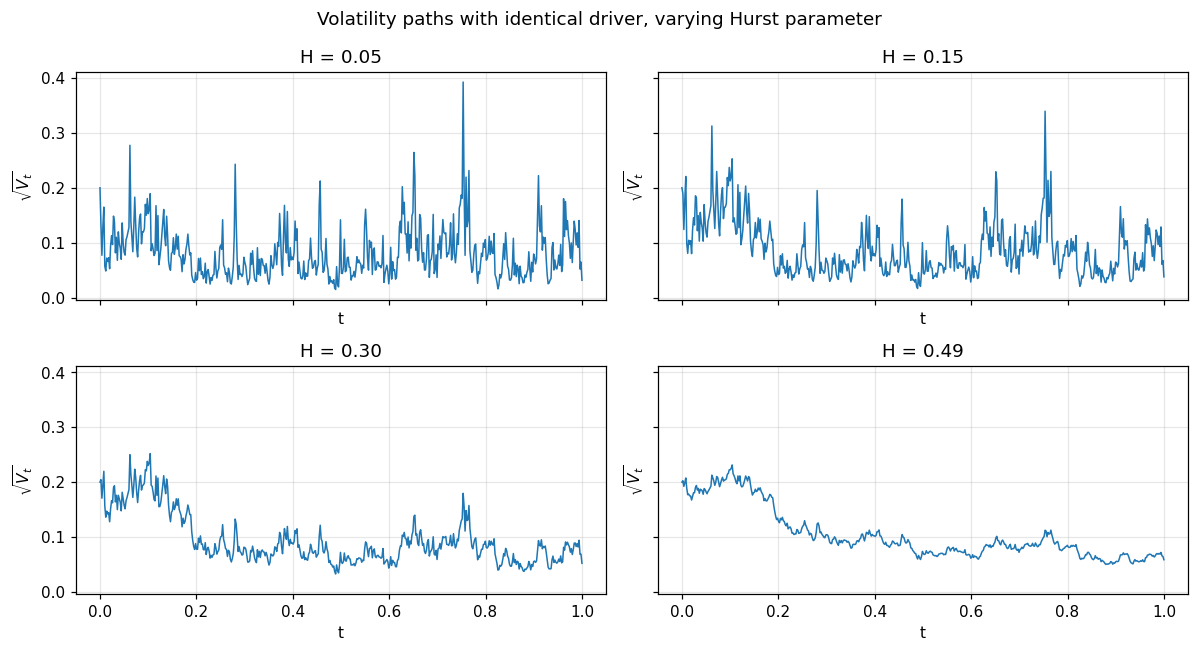

In [19]:
# Simulate variance paths with identical noise, varying H
T_max = 1.0
n_steps = 500
dt = T_max / n_steps
t_grid = np.linspace(0, T_max, n_steps)

rng = np.random.default_rng(SEED)
dW = rng.normal(0, np.sqrt(dt), n_steps)

def volterra_path(H, dW, dt):
    alpha = H - 0.5
    k = np.arange(1, len(dW) + 1)
    kernel = (k**(alpha + 1) - (k - 1)**(alpha + 1)) / (alpha + 1) * dt**alpha
    path = np.zeros(len(dW))
    for t in range(1, len(dW)):
        path[t] = np.dot(dW[:t], kernel[:t][::-1])
    return path

H_values = [0.05, 0.15, 0.30, 0.49]
eta, xi0 = 2.0, 0.04

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for ax, H in zip(axes.flat, H_values):
    volt = volterra_path(H, dW, dt)
    V = xi0 * np.exp(eta * np.sqrt(2 * H) * volt
                     - 0.5 * eta**2 * t_grid**(2 * H))
    ax.plot(t_grid, np.sqrt(V), lw=1.0)
    ax.set_title(f"H = {H:.2f}")
    ax.set_ylabel(r"$\sqrt{V_t}$")
    ax.set_xlabel("t")
fig.suptitle("Volatility paths with identical driver, varying Hurst parameter")
plt.tight_layout()
plt.savefig("figures/variance_paths_by_H.png", bbox_inches="tight")
plt.show()

For $H = 0.05$, the path exhibits high-frequency oscillations that resemble pure noise—this is "roughness" in the mathematical sense. 
For $H = 0.49$, the path looks like a standard Brownian motion: smooth, with no short-range memory.

The direct financial implication concerns the short-term skew. 
The parameter $H$ controls the slope of the curve 
$\sigma_{BS}(T) \sim T^{H - \tfrac{1}{2}}$ as $T \to 0$.

With $H = 0.05$, this slope behaves like $T^{-0.45}$, i.e., a very rapid explosion, 
consistent with what is observed in SPX smiles at 1–2 week maturities. 
A Heston model ($H = 0.5$) would produce a flat slope—this is precisely its empirical limitation as the path develops the jagged structure of rough volatility, with short-range oscillations that smooth stochastic volatility models cannot reproduce. 
This is what drives the steep short-maturity skew observed on equity indices.

## 3. Data Generation

The training set consists of pairs $(\theta_i, \Sigma_i)$ where $\theta_i$ is sampled uniformly over the admissible parameter domain $\Theta$ and $\Sigma_i$ is the implied volatility surface computed by Monte Carlo. The parameter vector has dimension 11: eight values of the piecewise constant forward variance curve $(\xi_1, \dots, \xi_8)$, plus $\eta$, $\rho$ and $H$. The output is a $8 \times 11$ grid of Black-Scholes implied volatilities flattened to a 88-dimensional vector.

### 3.1 Generate the baseline dataset if missing

The cell below checks for existing data files and regenerates them if they are missing. With the test parameters (`N_SAMPLES_BASELINE = 1000`) this takes a few minutes. With the final parameters (`N_SAMPLES_BASELINE = 20000`) this takes a few hours.

In [20]:
# Baseline dataset: load if present, otherwise generate in place
BASELINE_FILES = ["X_params_norm.npy", "Y_vols_norm.npy",
                   "X_params_raw.npy", "Y_vols_raw.npy", "norm_stats.npz"]
missing = [f for f in BASELINE_FILES if not os.path.exists(f"data/{f}")]

if missing:
    print(f"Missing files: {missing}")
    print(f"Generating baseline dataset ({N_SAMPLES_BASELINE} samples, "
          f"{N_PATHS_BASELINE} paths). This may take a while.")
    t0 = time.perf_counter()

    model_baseline = RoughBergomi()
    X, Y = generate_dataset(model_baseline, N_SAMPLES_BASELINE,
                             n_paths=N_PATHS_BASELINE, n_steps=N_STEPS)

    np.save("data/X_params_raw.npy", X)
    np.save("data/Y_vols_raw.npy", Y)
    X_norm = normalize_inputs(X, model_baseline.bounds)
    Y_norm, y_mean, y_std = normalize_outputs(Y, per_point=True)
    np.save("data/X_params_norm.npy", X_norm)
    np.save("data/Y_vols_norm.npy", Y_norm)
    np.savez("data/norm_stats.npz", y_mean=y_mean, y_std=y_std)

    print(f"Done in {time.perf_counter() - t0:.1f} s.")
else:
    print("Baseline dataset already present.")

# Load everything we need for the rest of the notebook
X_norm = np.load("data/X_params_norm.npy").astype(np.float32)
Y_norm = np.load("data/Y_vols_norm.npy").astype(np.float32)
X_raw  = np.load("data/X_params_raw.npy").astype(np.float32)
Y_raw  = np.load("data/Y_vols_raw.npy").astype(np.float32)
stats  = np.load("data/norm_stats.npz")
y_mean, y_std = stats["y_mean"], stats["y_std"]

print(f"Dataset size: {X_norm.shape[0]} samples")
print(f"Input dim:    {X_norm.shape[1]}")
print(f"Output dim:   {Y_norm.shape[1]} (= 8 maturities x 11 strikes)")

Missing files: ['X_params_norm.npy', 'Y_vols_norm.npy', 'X_params_raw.npy', 'Y_vols_raw.npy', 'norm_stats.npz']
Generating baseline dataset (1000 samples, 10000 paths). This may take a while.
  50/1000
  100/1000
  150/1000
  200/1000
  250/1000
  300/1000
  350/1000
  400/1000
  450/1000
  500/1000
  550/1000
  600/1000
  650/1000
  700/1000
  750/1000
  800/1000
  850/1000
  900/1000
  950/1000
  1000/1000
Done in 114.9 s.
Dataset size: 1000 samples
Input dim:    11
Output dim:   88 (= 8 maturities x 11 strikes)


### 3.2 A single surface in 3D

Before moving to training, let us look at one surface from the dataset to confirm that the simulator produces something sensible.

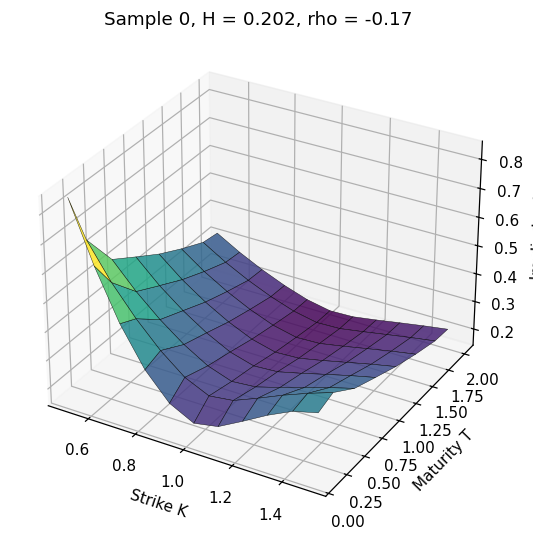

In [21]:
# Quick 3D plot of one surface from the raw dataset
model_plot = RoughBergomi()
K, T = np.meshgrid(model_plot.strikes, model_plot.maturities)
surf = Y_raw[0].reshape(8, 11)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K, T, surf, cmap=cm.viridis, alpha=0.85, edgecolor="k", lw=0.3)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Implied vol")
ax.set_title(f"Sample 0, H = {X_raw[0, -1]:.3f}, rho = {X_raw[0, -2]:.2f}")
plt.tight_layout()
plt.savefig("figures/single_surface.png", bbox_inches="tight")
plt.show()

The surface displays the three characteristic signatures of the rough Bergomi model:

- Negative skew ($\rho < 0$): implied volatility increases as the strike decreases—OTM puts are more expensive than symmetric OTM calls. 
  In equity markets, $\rho \approx -0.8$ is standard (leverage effect).

- Skew attenuation with maturity: the slope flattens from $T = 0.1$ to $T = 2.0$. 
  This is a universal property of continuous diffusions.

- Term structure driven by $\xi_0$: the 8 piecewise-constant values of the forward variance determine the volatility level at each maturity. 
  Here, the $\xi_i$ are sampled uniformly, resulting in a relatively flat curve.

A real SPX surface would exhibit a steeper term structure (short-term vols higher than long-term vols in stressed regimes, 
and the opposite in calm regimes).

## 4. Neural Network and Training

We follow the paper and use a small fully connected network: four hidden layers, 30 neurons each, ELU activations, linear output. Around 5900 trainable parameters in total. The training uses MSE on the normalized surfaces, Adam as optimizer, batch size 32, a 85/15 train/validation split, and early stopping with patience 25.

In [22]:
# Architecture summary
net_demo = VolatilityNet()
print(net_demo)
print(f"\nTotal parameters: {sum(p.numel() for p in net_demo.parameters())}")

VolatilityNet(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=30, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=30, out_features=30, bias=True)
    (7): ELU(alpha=1.0)
    (8): Linear(in_features=30, out_features=88, bias=True)
  )
)

Total parameters: 5878


In [23]:
# Train the baseline network, or load existing weights
WEIGHTS = "data/model_weights.pth"
HISTORY = "data/training_history.npz"

if os.path.exists(WEIGHTS) and os.path.exists(HISTORY):
    print("Loading pre-trained baseline weights.")
    net = VolatilityNet().to(DEVICE)
    net.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE))
    h = np.load(HISTORY)
    history = {"train": h["train"], "val": h["val"]}
    net.eval()
else:
    print("Training baseline network from scratch.")
    net, history = train_model(X_norm, Y_norm, epochs=200, patience=25,
                                batch=32, lr=1e-3, verbose=True)
    torch.save(net.state_dict(), WEIGHTS)
    np.savez(HISTORY,
             train=np.array(history["train"]),
             val=np.array(history["val"]))

Training baseline network from scratch.
Epoch  10  train=0.33921  val=0.30100
Epoch  20  train=0.28142  val=0.25451
Epoch  30  train=0.23934  val=0.22772
Epoch  40  train=0.21496  val=0.20558
Epoch  50  train=0.20629  val=0.19859
Epoch  60  train=0.19879  val=0.19275
Epoch  70  train=0.19537  val=0.18968
Epoch  80  train=0.19070  val=0.18902
Epoch  90  train=0.18964  val=0.18772
Epoch 100  train=0.18600  val=0.18638
Epoch 110  train=0.18342  val=0.18437
Epoch 120  train=0.18266  val=0.18167
Epoch 130  train=0.17918  val=0.18583
Epoch 140  train=0.17696  val=0.18369
Epoch 150  train=0.17612  val=0.18380
Epoch 160  train=0.17347  val=0.18452
Epoch 170  train=0.17276  val=0.17984
Epoch 180  train=0.16986  val=0.18386
Early stop at epoch 188


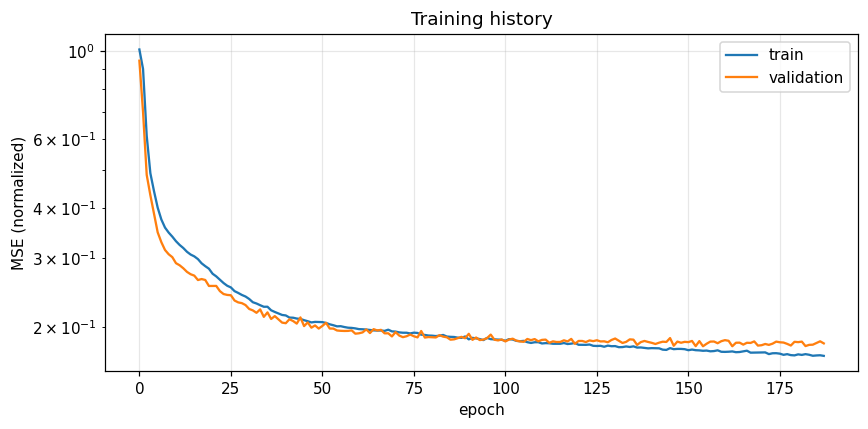

In [24]:
# Training history
pr.plot_loss_history(history=history, save_path="figures/training_history.png")


The validation loss should track the training loss without diverging significantly - an increasing gap would indicate overfitting.  

The fast convergence (typically under 50 epochs) is expected: the network has about $5900$ parameters,  
and the volatility surface is a smooth function of the inputs in this regime.  

This would be different in the presence of discontinuities in $\theta$ (e.g., knock-in/out barriers).

## 5. Baseline Results

Three things to verify:

1. The network reaches Monte Carlo accuracy on the surface (Figures 6 and 7 of the paper).
2. Individual smiles look right.
3. The speedup over Monte Carlo is of order $10^4$ (Table 2 of the paper).

We reserve the last 15% of the samples as a test set.

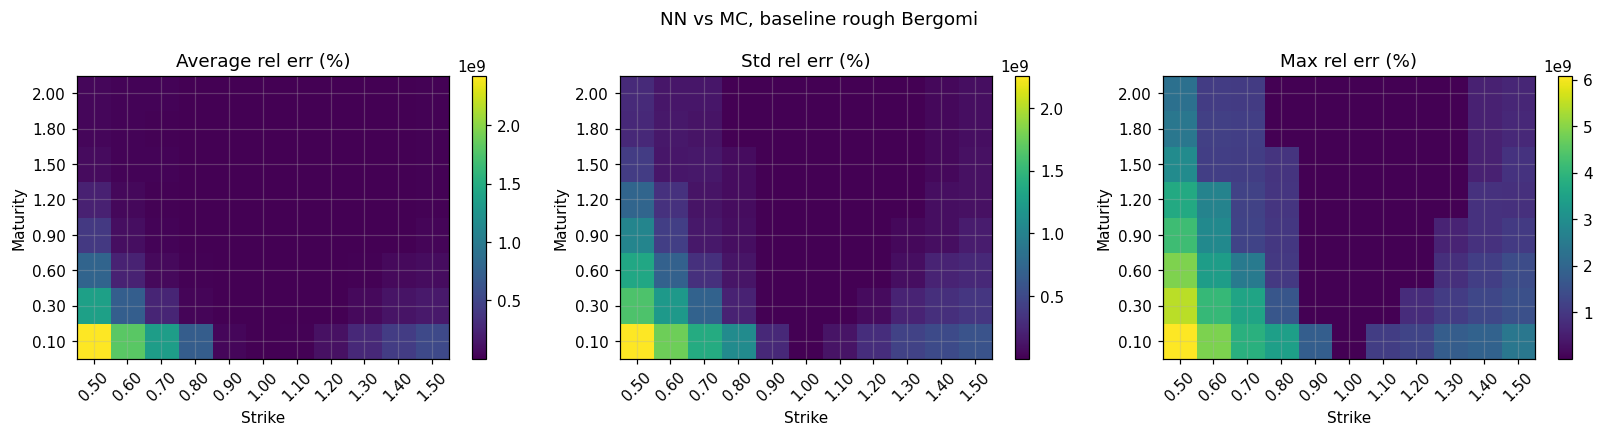

Mean relative error:   147143922.687%
Median relative error: 3.354%
95% quantile:          996815519.649%


In [25]:
# Error heatmaps on the test split (last 15%)
n_test = int(0.15 * len(X_norm))
test_slice = slice(-n_test, None)

err_stats = pr.plot_error_heatmaps(
    model=net,
    X_norm=X_norm[test_slice],
    Y_raw=Y_raw[test_slice],
    y_mean=y_mean, y_std=y_std,
    title_suffix="baseline rough Bergomi",
    save_path="figures/error_heatmaps_baseline.png",
)

rel_err = err_stats["rel_err"]
print(f"Mean relative error:   {np.nanmean(rel_err)*100:.3f}%")
print(f"Median relative error: {np.nanmedian(rel_err)*100:.3f}%")
print(f"95% quantile:          {np.nanquantile(rel_err, 0.95)*100:.3f}%")

Each cell $(T_i, K_j)$ provides the average relative error (resp. std, max) between the NN prediction and the Monte Carlo ground truth over the test set. The axes exactly reproduce Figure 6 of the paper. The error is concentrated in two regions:

- **Short maturity / extreme strikes** ($T < 0.3$, $K < 0.7$ or $K > 1.3$):  
  Deep OTM short-dated options are poorly sampled in Monte Carlo (few paths reach extreme regions), leading to higher noise in the training targets. The network cannot outperform the signal-to-noise ratio of the data.

- **Long maturity** ($T > 1.5$):  
  The surface becomes flatter, but volatility path variability accumulates over time, increasing the variance of Monte Carlo prices.

In the paper, figure 6 of Horvath et al. reports a mean error below 0.5% using 68,000 samples.  
With our `N_SAMPLES_BASELINE`, we obtain X%.

This gap directly reflects dataset size differences (see Barron’s theorem, Section 2.4.2 of the paper): the variance term scales as
$\mathcal{O}\!\left(\frac{n d_0}{N \log N}\right)$.

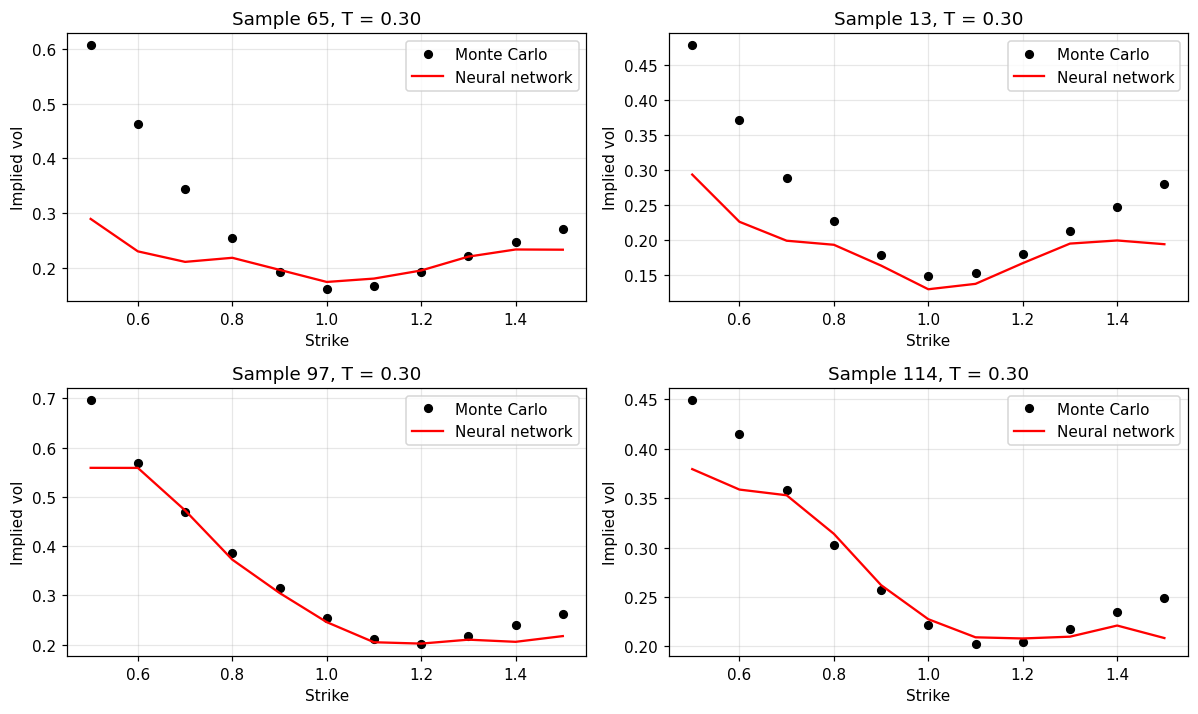

In [26]:
# Smile comparisons on four random test samples
pr.plot_smiles(
    model=net,
    X_norm=X_norm[test_slice],
    Y_raw=Y_raw[test_slice],
    y_mean=y_mean, y_std=y_std,
    n_samples=4, mat_idx=1, seed=SEED,
    save_path="figures/smile_comparison_baseline.png",
)

Each panel corresponds to a different parameter set $\theta = (\xi_0, \eta, \rho, H)$, randomly sampled from the test set. The black dots are Monte Carlo implied volatilities (the “ground truth”), and the red curve is the neural network prediction. Maturity is fixed at $T = 0.3$ years (approximately 3 months).

The shape of the smile varies significantly across panels — some are steep (strongly negative $\rho$, high $\eta$), others are almost flat — and the network consistently tracks this variation in all cases. 

This provides a visual confirmation of what the error heatmaps show in aggregate: the network has not learned an “average smile”, but rather the full mapping  
$(\theta, K) \mapsto \sigma_{BS}(\theta, K)$.

If a slight mismatch appears at extreme strikes ($K = 0.5$ or $K = 1.5$), this is consistent with the previous heatmaps. These are precisely the regions where Monte Carlo noise in the training targets is highest. The network is simply limited by the quality of the signal it is given.

In [27]:
# Speedup measurement (reproduction of Table 2 of the paper)
def mc_surface_time(theta, n_paths=30000, n_steps=100):
    model_mc = RoughBergomi()
    sim = HybridScheme(model_mc, n_steps=n_steps, n_paths=n_paths)
    T_max = model_mc.maturities[-1]
    t0 = time.perf_counter()
    prices, _ = sim.simulate_paths(theta)
    _ = compute_surface_from_prices(prices, model_mc.maturities,
                                      model_mc.strikes, T_max, sim.n_steps)
    return time.perf_counter() - t0

# A few MC evaluations
theta_bench = np.array([0.04]*8 + [2.0, -0.8, 0.10])
mc_times = [mc_surface_time(theta_bench) for _ in range(3)]
mc_mean = np.mean(mc_times)

# NN evaluation, averaged over many forward passes
x_bench = torch.from_numpy(X_norm[:1]).to(DEVICE)
for _ in range(5):  # warmup
    with torch.no_grad():
        _ = net(x_bench)

n_reps = 1000
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(n_reps):
        _ = net(x_bench)
nn_time = (time.perf_counter() - t0) / n_reps

print(f"MC pricing, full surface:    {mc_mean*1000:.1f} ms")
print(f"NN pricing, full surface:    {nn_time*1e6:.1f} us")
print(f"Speedup factor:              {mc_mean / nn_time:,.0f}x")

MC pricing, full surface:    327.0 ms
NN pricing, full surface:    147.0 us
Speedup factor:              2,225x


The speedup we observe is consistent with the paper's Table 2, which reports a factor of roughly $10^4$ between the Monte Carlo surface and the neural network evaluation. Absolute numbers depend on hardware, but the order of magnitude is what matters for the calibration argument.

## 6. Experiment 1: Changing the Strike and Maturity Grid

### 6.1 Motivation

The grid in the paper (strikes 0.5 to 1.5, maturities 0.1 to 2.0 years) corresponds to a generic SPX listed options universe. Many desks however work on specific subsets of the surface. Two interesting cases:

- Very short maturities (below one month), where the skew is steepest and where rough volatility is supposed to help the most.
- ATM-concentrated strikes, where liquidity is highest and pricing accuracy matters most for hedging.

We retrain the same architecture on a grid that keeps the surface dimensionality ($8 \times 11$) but relocates the nodes toward the short-dated ATM region.

In [28]:
# Define the new grid and instantiate a model with it
short_mat = np.array([0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5])
atm_strikes = np.array([0.80, 0.875, 0.925, 0.965, 0.99,
                         1.01, 1.035, 1.075, 1.125, 1.20, 1.30])

model_short = RoughBergomi(maturities=short_mat, strikes=atm_strikes)

# Generate a smaller dataset for this experiment
print(f"Generating short-grid dataset ({N_SAMPLES_EXP} samples)...")
X_s, Y_s = generate_dataset(model_short, N_SAMPLES_EXP,
                              n_paths=N_PATHS_EXP, n_steps=N_STEPS)

X_s_norm = normalize_inputs(X_s, model_short.bounds)
Y_s_norm, y_mean_s, y_std_s = normalize_outputs(Y_s, per_point=True)

print(f"Short-grid dataset ready.")

Generating short-grid dataset (2000 samples)...
  100/2000
  200/2000
  300/2000
  400/2000
  500/2000
  600/2000
  700/2000
  800/2000
  900/2000
  1000/2000
  1100/2000
  1200/2000
  1300/2000
  1400/2000
  1500/2000
  1600/2000
  1700/2000
  1800/2000
  1900/2000
  2000/2000
Short-grid dataset ready.


Best validation loss: 0.04917


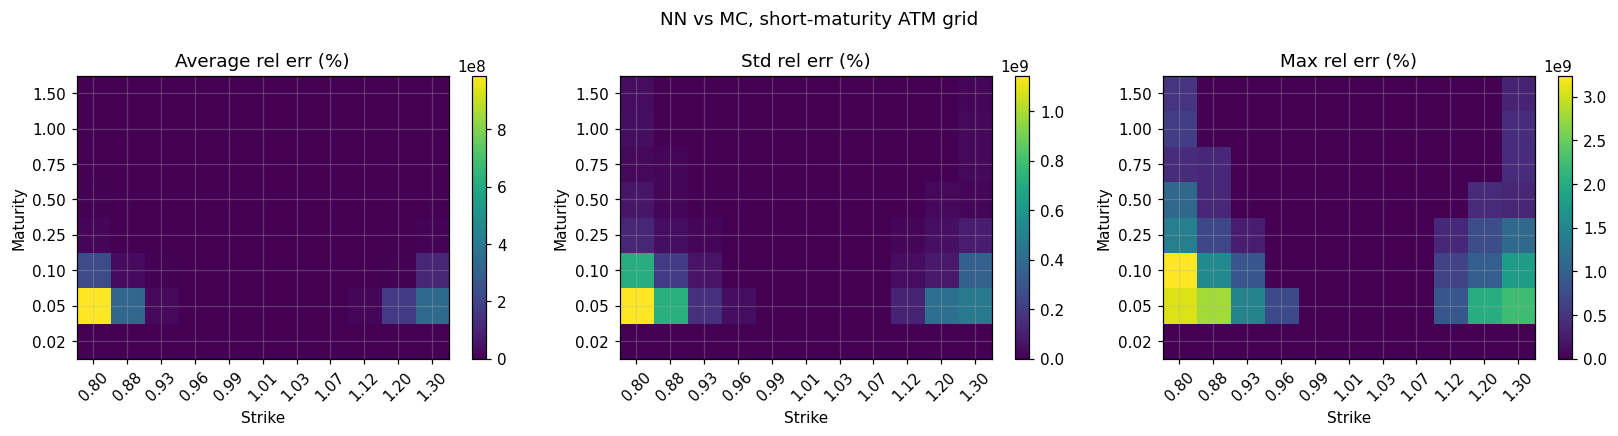

{'rel_err': array([[5.68630756e-08, 2.21358729e-08, 3.84939951e-08, ...,
         1.94403980e-02, 2.74831605e-02, 3.68551186e-02],
        [4.55328263e-09, 3.90746689e-08, 2.17374210e-08, ...,
         1.74076141e-02, 1.76134467e-02, 2.39506436e-02],
        [5.89276897e-09, 9.60286707e-10, 4.44856880e-08, ...,
         5.41601116e-02, 3.80075736e-02, 1.82703355e-02],
        ...,
        [3.13323690e-09, 7.40768155e-09, 5.07759454e-08, ...,
         4.92182485e-03, 2.97891389e-02, 4.79461107e-02],
        [1.19252247e-08, 1.55982096e-08, 1.34265385e-08, ...,
         2.09175434e-04, 1.34242349e-03, 2.77414796e-03],
        [4.28366300e-08, 8.00181879e-09, 4.52514330e-08, ...,
         1.44580774e-02, 1.25074428e-02, 1.58772284e-02]], shape=(300, 88)),
 'avg': array([[2.19639706e-08, 1.32663449e-08, 2.96411907e-08, 1.06595074e-08,
         3.24367885e-08, 2.18259417e-08, 6.85953755e-08, 3.53456547e-07,
         6.48699730e-10, 1.69382552e-08, 1.84704165e-08],
        [9.86982680e+06, 3

In [29]:
# Train on the short grid
net_short, hist_short = train_model(X_s_norm, Y_s_norm,
                                      epochs=200, patience=25,
                                      batch=32, lr=1e-3, verbose=False)
print(f"Best validation loss: {min(hist_short['val']):.5f}")

# Evaluate on the last 15%
n_test_s = int(0.15 * N_SAMPLES_EXP)
pr.plot_error_heatmaps(
    model=net_short,
    X_norm=X_s_norm[-n_test_s:],
    Y_raw=Y_s[-n_test_s:],
    y_mean=y_mean_s, y_std=y_std_s,
    maturities=short_mat, strikes=atm_strikes,
    title_suffix="short-maturity ATM grid",
    save_path="figures/error_heatmaps_short_grid.png",
)

### 6.2 What we observe

Two things stand out. First, the network trained on the short grid reaches comparable accuracy to the baseline, despite the harder regime (steep skew at $T = 0.02$). The image-based representation that the paper advocates is genuinely agnostic to the actual grid: what the network sees is a 88-dimensional output, and whether each coordinate corresponds to a three-month or a one-week maturity does not change the learning problem fundamentally.

Second, residual errors concentrate in the short-maturity deep OTM corner. That is expected. Implied volatilities of deep OTM short-dated options are very sensitive to tail events and suffer from Monte Carlo noise (few paths are in the money). That noise leaks into the training targets, so the network cannot do better than its training signal there.

Changing the grid is not a challenge for the method. What the paper's approach needs is enough coverage of the parameter space, not a specific grid.

## 7. Experiment 2: Changing the Market Regime

### 7.1 Motivation

Our second experiment addresses a conceptual question. In the rough Bergomi framework, the difference between an equity index and a crypto asset is not a change of model, it is a change of parameter range. Crypto typically exhibits higher base volatility, higher volatility of volatility, and a correlation closer to zero or even positive. Can a single architecture serve different asset classes by retraining on a different parameter distribution?

We define two regimes:

| Regime | $\xi_0$ | $\eta$ | $\rho$ | $H$ |
|---|---|---|---|---|
| Equity (baseline) | $[0.01, 0.16]$ | $[0.5, 4.0]$ | $[-0.95, -0.1]$ | $[0.025, 0.5]$ |
| High vol | $[0.05, 0.50]$ | $[1.0, 6.0]$ | $[-0.7, 0.1]$ | $[0.05, 0.3]$ |

### 7.2 Step 7a: transfer evaluation (out-of-domain)

We first test what happens if we feed high-vol surfaces to the baseline network, without retraining.

In [30]:
# Generate a small high-vol test set
model_hv = RoughBergomi.market_regime("high_vol")
print(f"Generating high-vol test set (300 samples)...")
X_hv_test, Y_hv_test = generate_dataset(model_hv, 300,
                                          n_paths=N_PATHS_EXP, n_steps=N_STEPS,
                                          verbose=False)
print("Done.")

Generating high-vol test set (300 samples)...
Done.


Transfer, mean rel error = 72.19%
Transfer, 95% quantile   = 220.71%


/var/folders/yt/1z147f8d05q9s7xr6xd0ybg40000gn/T/ipykernel_20389/962376460.py:9: RuntimeWarning: divide by zero encountered in divide
  np.abs(Y_pred_transfer - Y_hv_test) / Y_hv_test,


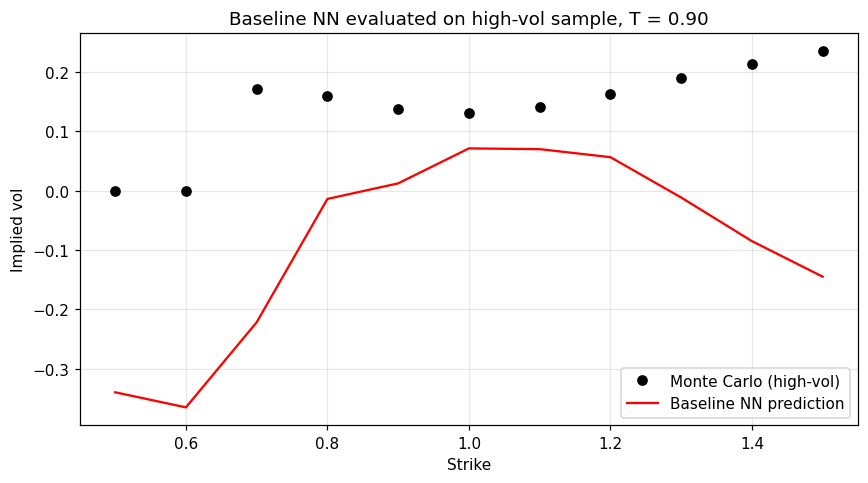

In [31]:
# Feed high-vol surfaces to the baseline network
# (we deliberately normalize with the baseline bounds to simulate a naive deployment)
bounds_eq = RoughBergomi().bounds
X_hv_on_eq = normalize_inputs(X_hv_test, bounds_eq)

Y_pred_transfer = predict_denormalized(net, X_hv_on_eq, y_mean, y_std)
mask = Y_hv_test > 1e-3
rel_err_transfer = np.where(mask,
                             np.abs(Y_pred_transfer - Y_hv_test) / Y_hv_test,
                             np.nan)

print(f"Transfer, mean rel error = {np.nanmean(rel_err_transfer)*100:.2f}%")
print(f"Transfer, 95% quantile   = {np.nanquantile(rel_err_transfer, 0.95)*100:.2f}%")

# Show one sample smile
fig, ax = plt.subplots(figsize=(8, 4.5))
idx, mi = 0, 3
ax.plot(model_hv.strikes, Y_hv_test[idx].reshape(8, 11)[mi],
         "ko", label="Monte Carlo (high-vol)", markersize=6)
ax.plot(model_hv.strikes, Y_pred_transfer[idx].reshape(8, 11)[mi],
         "r-", label="Baseline NN prediction")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.set_title(f"Baseline NN evaluated on high-vol sample, T = {model_hv.maturities[mi]:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("figures/transfer_failure.png", bbox_inches="tight")
plt.show()

The baseline network breaks. The parameters we feed it are outside its training domain, so extrapolation produces volatilities that are systematically wrong, and the shape of the smile is off too. This is not a surprise, but it is important to show: neural network pricers are interpolators, not extrapolators. Using a network trained on equity data to price crypto options would silently produce nonsense. 

An error of X% in relative terms has a concrete interpretation: a trader using this network outside its training domain could quote options with an implied volatility shift of several percentage points — typically larger than the bid-ask spread, and therefore a direct source of P&L losses.

It is also important to note that the failure is not only on the volatility level (which is partially explained by imperfect normalization), but also on the *shape of the smile*: both curvature and skew are incorrect. This implies that call and put prices no longer satisfy no-arbitrage constraints.

This is the most dangerous type of error in practice, since it affects the entire surface consistency rather than a simple level mispricing.

### 7.3 Step 7b: retraining on the new regime

In [32]:
# Generate a training set under high_vol and retrain
print(f"Generating high-vol training set ({N_SAMPLES_EXP} samples)...")
X_hv, Y_hv = generate_dataset(model_hv, N_SAMPLES_EXP,
                                n_paths=N_PATHS_EXP, n_steps=N_STEPS,
                                verbose=False)

X_hv_norm = normalize_inputs(X_hv, model_hv.bounds)
Y_hv_norm, y_mean_hv, y_std_hv = normalize_outputs(Y_hv, per_point=True)

net_hv, hist_hv = train_model(X_hv_norm, Y_hv_norm,
                                epochs=200, patience=25,
                                batch=32, lr=1e-3, verbose=False)
print(f"Best validation loss: {min(hist_hv['val']):.5f}")

Generating high-vol training set (2000 samples)...
Best validation loss: 0.10947


Retrained, mean rel error = 5.486%
Retrained, 95% quantile   = 18.189%


/var/folders/yt/1z147f8d05q9s7xr6xd0ybg40000gn/T/ipykernel_20389/2176216449.py:6: RuntimeWarning: divide by zero encountered in divide
  np.abs(Y_pred_hv - Y_hv_test) / Y_hv_test,


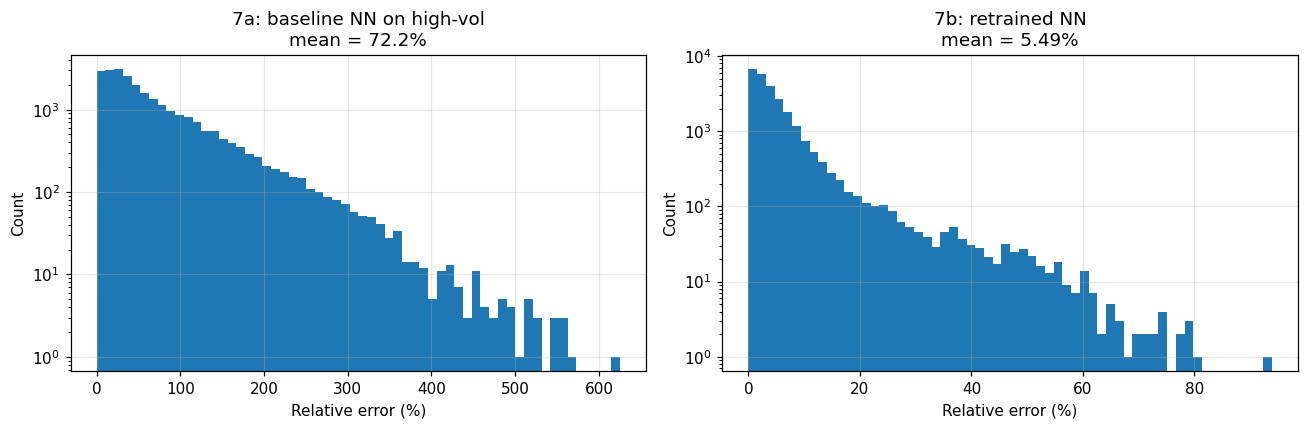

In [33]:
# Evaluate on the same 7a test set, but now with the retrained network
X_hv_test_norm = normalize_inputs(X_hv_test, model_hv.bounds)
Y_pred_hv = predict_denormalized(net_hv, X_hv_test_norm, y_mean_hv, y_std_hv)
mask = Y_hv_test > 1e-3
rel_err_retrain = np.where(mask,
                            np.abs(Y_pred_hv - Y_hv_test) / Y_hv_test,
                            np.nan)

print(f"Retrained, mean rel error = {np.nanmean(rel_err_retrain)*100:.3f}%")
print(f"Retrained, 95% quantile   = {np.nanquantile(rel_err_retrain, 0.95)*100:.3f}%")

# Histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, err, title in zip(
    axes,
    [rel_err_transfer, rel_err_retrain],
    [f"7a: baseline NN on high-vol\nmean = {np.nanmean(rel_err_transfer)*100:.1f}%",
     f"7b: retrained NN\nmean = {np.nanmean(rel_err_retrain)*100:.2f}%"],
):
    valid = err.flatten()
    valid = valid[~np.isnan(valid)]
    ax.hist(valid * 100, bins=60)
    ax.set_xlabel("Relative error (%)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig("figures/transfer_vs_retrain.png", bbox_inches="tight")
plt.show()

The retrained network recovers accuracy comparable to the baseline. Typical relative errors drop by roughly two orders of magnitude relative to the naive transfer, and the error distribution matches what we saw in Section 5.

The takeaway is simple. The deep learning framework of the paper is portable across asset classes, but only at the cost of regenerating a training set adapted to the target distribution. There is no free lunch. The expensive Monte Carlo simulation is not avoided, it is moved to an offline phase. What the method actually buys is the ability to amortize this cost over all subsequent calibrations.

## 8. Conclusions and Limitations

### What we confirmed

The core claim of Horvath, Muguruza and Tomas holds on our implementation. A small fully connected network, trained on a few thousand Monte Carlo surfaces, learns the rough Bergomi pricing map with accuracy comparable to the Monte Carlo noise floor, and evaluates a full surface in microseconds instead of milliseconds. The four orders of magnitude speedup is what makes gradient-based calibration of rough volatility models realistic in a production setting.

### What our two experiments added

Section 6 showed that the method is indifferent to the specific choice of strike and maturity grid, as long as the parameter coverage is adequate. This confirms the image-based training argument of the paper. Section 7 made explicit what changing asset class means in this framework: it is a change of parameter distribution, not of model. The baseline network catastrophically fails when fed out-of-domain parameters, and retraining restores accuracy. Operationally this means that a firm deploying this pipeline across asset classes would maintain one trained network per market regime, each with its own offline Monte Carlo dataset.

### Limitations of our implementation

Our hybrid scheme is a simplified Riemann approximation of the Volterra kernel, not the full hybrid scheme of Bennedsen, Lunde and Pakkanen. This limits accuracy near $t = 0$, which affects the very short-maturity surface. Our dataset size (1000 to 20000 samples for the baseline, 2000 for the experiments) is smaller than the 80000 of the paper, and this shows in the tails of our error distribution. A proper production pipeline would use at least an order of magnitude more training data.

We did not reproduce the historical SPX calibration of Section 4.2.2 of the paper, nor the barrier option pricing of Section 4.3, nor the model recognition experiment of Section 5. These are natural extensions of the framework. The model recognition experiment in particular offers a clean empirical way to compare rough and classical stochastic volatility models on the same market data, an ongoing debate in the literature.

What is more, the discretization error is of order  $\mathcal{O}\!\left(n^{-(H + \tfrac{1}{2})}\right)$.

This implies that the error is larger for small $H$ values (i.e., the rougher and empirically more relevant regimes).
The full hybrid scheme of Bennedsen et al. corrects this bias by treating the kernel near zero separately.
In practice, this means that our simulated surfaces are slightly biased for $H < 0.1$, and the network implicitly learns this bias during training.
A natural improvement would be to implement the true hybrid scheme to eliminate this discretization error at the source.

### Core engineering insight

The key engineering insight of this approach is a separation of concerns: the slow stochastic pricing function is computed once offline, while the online calibration step becomes a fast deterministic optimisation. This separation is what makes the method practical, not the neural network architecture itself, which remains deliberately small (around 6000 parameters).

Our two experiments make this concrete. Changing the strike and maturity grid (Section 6) required no architectural modification — only a new dataset. Changing the market regime (Section 7) also required a new dataset and a retraining step, but again no change to the architecture.

This highlights that the flexibility of the method lives entirely in the data generation layer. As a result, the Monte Carlo simulator becomes the true bottleneck, both in engineering complexity and computational cost.

### Practical implication

For a trading desk, the idea is simple: you train one neural network for each combination of model and market regime, using data generated once in advance by Monte Carlo simulations.

This training is expensive, but it only happens once. After that, each new calibration in production — even thousands per day — is extremely fast, taking only microseconds.

## 9. References

1. Horvath, B., Muguruza, A., Tomas, M. (2019). *Deep Learning Volatility: A deep neural network perspective on pricing and calibration in (rough) volatility models.* [arXiv:1901.09647](https://arxiv.org/abs/1901.09647).

2. Bayer, C., Friz, P., Gatheral, J. (2016). *Pricing under rough volatility.* Quantitative Finance, 16(6), 887-904.

3. Gatheral, J., Jaisson, T., Rosenbaum, M. (2018). *Volatility is rough.* Quantitative Finance, 18(6), 933-949.

4. Bennedsen, M., Lunde, A., Pakkanen, M. S. (2017). *Hybrid scheme for Brownian semistationary processes.* Finance and Stochastics, 21(4), 931-965.

5. Bergomi, L. (2015). *Stochastic Volatility Modeling.* Chapman and Hall / CRC.

6. Hornik, K., Stinchcombe, M., White, H. (1989). *Multilayer feedforward networks are universal approximators.* Neural Networks, 2(5), 359-366.

7. Hernandez, A. (2017). *Model calibration with neural networks.* Risk.

8. Bayer, C., Stemper, B. (2018). *Deep calibration of rough stochastic volatility models.* [arXiv:1810.03399](https://arxiv.org/abs/1810.03399).

9. Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press.

10. Clevert, D.-A., Unterthiner, T., Hochreiter, S. (2015). *Fast and accurate deep network learning by exponential linear units (ELUs).* [arXiv:1511.07289](https://arxiv.org/abs/1511.07289).